# 02 — Univariate bias adjustment

Application of three univariate bias-adjustment methods: empirical quantile mapping (EQM), detrended quantile mapping (DQM), and quantile delta mapping (QDM), using two-fold cross-validation.

Two strategies are illustrated:

1. **Indirect adjustment:** adjust maximum temperature and humidity separately and calculate the heat-stress index afterwards. Relative humidity is  derived from temperature and specific humidity.
2. **Direct adjustment:** calculate the heat-stress index from the raw input variables and adjust the resulting index directly.

This notebook uses WBT as the direct-approach example and REMO2015 driven by NorESM1-M as the model example.

Note that `huss` refers to daily specific humidity and `tasmax` to daily maximum near-surface air temperature. In this analysis, `hurs` represents an estimate of daily minimum relative humidity derived from `tasmax` and `huss`. This combination is used as a proxy for the atmospheric conditions occurring near the time of daily maximum heat stress.

In [1]:
options(java.parameters = "-Xmx32g")

rm(list = ls())
graphics.off()
invisible(gc())

library(loadeR)
library(visualizeR)
library(transformeR)
library(downscaleR)
require(HeatStress)
library(magrittr)
library(climate4R.indices)

Loading required package: rJava

Loading required package: loadeR.java

Java version 11x amd64 by Oracle Corporation detected

The maximum JVM heap space available is: 32.00 GB

NetCDF Java Library Version: 4.6.0-SNAPSHOT (Built-On: 20150423.1338) loaded and ready

You can manually set the NetCDF Java Library version before loading the package:
options(loadeR.java_forced_version = "X.Y.Z")
library(loadeR.java)

netCDF-Java CLASSPATH from bundled java package directory: /nfs/home/gmeteo/balmacedar/micromamba/envs/R363-climate4R/lib/R/library/loadeR.java/java:/nfs/home/gmeteo/balmacedar/micromamba/envs/R363-climate4R/lib/R/library/loadeR.java/java/netcdfAll-4.6.0-SNAPSHOT.jar

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.3 (2021-07-05) is loaded


Get the latest stable version (0.2.4) using <devtools::install_github('SantanderMetGroup/climate4R.UDG')>

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.7.1 (2021-07-05) is loaded


Get the


    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.1.2 (2021-07-07) is loaded


Get the latest stable version (2.2.5) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

Warning message:
“no DISPLAY variable so Tk is not available”
visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.

downscaleR version 3.3.2 (2020-06-05) is loaded


Get the latest stable version (3.3.4) using <devtools::install_github(c('SantanderMetGroup/transformeR','SantanderMetGroup/downscaleR'))>

Please use 'citation("downscaleR")' to cite this package.

Loading required package: HeatStress

HeatStress version 1.0.8.1 (2025-08-13) is loaded

Use 'indexShow()' for an overview of the available heat indices

climate4R.indices version 0.3.1 (2023-06-22) is loaded


Get the latest stable version (0.3.2) using <devtools::install_github('SantanderMetGroup/climate4R.indices')>

Use 'indexShow()' for an overview of the ava

## Setup

Run `01_data_preparation.ipynb` first. Then edit the paths and simulation identifiers below.

In [ ]:
# Analysis settings
years <- 1982:2005
season <- c(12, 1, 2)
folds <- list(1982:1993, 1994:2005)
methods <- c("eqm", "dqm", "qdm")

experiment <- "CrosVal"
sesa_lon <- c(-64, -45)
sesa_lat <- c(-40, -18)
# Simulation labels used in output filenames
gcm_id <- "NorESM1"
rcm_id <- "REMO"
vars=c("tasmax", "huss", "hurs")

# Input/output paths
data_dir <- "prepared_data"
output_dir <- "bias_adjusted/univariate"
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

obs_tasmax_file <- file.path(data_dir, "Datos_CV_BA_tasmax_MSWX.rda")
obs_huss_file <- file.path(data_dir, "Datos_CV_BA_huss_MSWX.rda")
model_tasmax_file <- file.path(data_dir, "Datos_tasmax_REMO2015_NCC-NorESM1-M.rda")
model_huss_file <- file.path(data_dir, "Datos_huss_REMO2015_NCC-NorESM1-M.rda")

##  Helper functions

In [2]:
## Estimated hurs from tasmax y hus/huss
calc_RH <- function(tas_grid, hus_grid) {
  HR <- huss2hurs(huss = as.vector(hus_grid$Data),
                  tas  = as.vector(tas_grid$Data), ps = 1013)
  hus_grid$Data <- array(HR, dim = dim(hus_grid$Data))
  attributes(hus_grid$Data)=attributes(tas_grid$Data)
  hus_grid
}

## Estimated wbt from tasmax y hus/huss
calc_wbt <- function(tas_grid, hus_grid) {
  HR <- huss2hurs(huss = as.vector(hus_grid$Data),
                  tas  = as.vector(tas_grid$Data), ps = 1013)
  sw <- wbt.Stull(as.vector(tas_grid$Data), hurs = HR)
  hus_grid$Data <- array(sw, dim = dim(hus_grid$Data))
  attributes(hus_grid$Data)=attributes(tas_grid$Data)
  hus_grid
}

## Estimated wbt from tasmax and relative humidity
calc_wbt_hurs <- function(tas_grid, hurs_grid) {
  sw <- wbt.Stull(as.vector(tas_grid$Data),
                  hurs = as.vector(hurs_grid$Data))
  out <- tas_grid
  out$Data <- array(sw, dim = dim(tas_grid$Data))
  attributes(out$Data) <- attributes(tas_grid$Data)
  out
}

#save data
output_name <- function(variable, method, approach) {
  file.path(
    output_dir,
    paste(variable, rcm_id, method, gcm_id, experiment, approach, "SESA.rda", sep = "_")
  )
}



##  Diagnostic functions

In [3]:
aggregate_djf_Ind27 <- function(grid) {
  
  # Define the ocean mask from the original daily data
  ocean_mask <- apply(
    is.na(grid$Data),
    MARGIN = 2:length(dim(grid$Data)),
    FUN = all
  )
  
  #  Calculate the number of days with WBT >= 27 °C
  ind <- indexGrid(
    tx = grid,
    time.resolution = "year",
    index.code = "TXth",
    th = 27
  )
  
  #  Repeat the spatial mask for every year
  ocean_mask_array <- array(
    rep(ocean_mask, each = dim(ind$Data)[1]),
    dim = dim(ind$Data)
  )
  
  # Apply the mask to the final result
  ind$Data[ocean_mask_array] <- NA_real_
  
  # 4. Convert to percentage
  ind <- gridArithmetics(ind, 90, operator = "/")
  ind <- gridArithmetics(ind, 100, operator = "*")
  
  # Replace non-finite values (Inf, -Inf) with 0
  ind$Data[!is.finite(ind$Data) & !is.na(ind$Data)] <- 0

  return(ind)
}

### Cross-validation 

The 24 austral summers are divided into two 12-year folds: 1982–1993 and 1994–2005. In each iteration, one fold is used for calibration and the other for validation. 

## Indirect univariate adjustment of WBT. 
Adjust tasmax and huss separately, then calculate WBT from adjusted variables.

In [5]:
approach='indirect'
methods_to_run <- 'eqm'  # use "eqm" here for a quick test

ba_indirect <- setNames(vector("list", length(vars)), vars)

In [6]:
for (var in vars){

if(var=='huss'){
  obs=get(load(obs_huss_file))
}

if(var=='tasmax'){
  obs=get(load(obs_tasmax_file))
}

if(var=='hurs'){
  obs.huss=get(load(obs_huss_file))
  obs.Tx=get(load(obs_tasmax_file))

# Synchronize temperature and humidity before deriving RH
  obs.huss=getTemporalIntersection(obs =obs.Tx,prd=obs.huss,which.return = 'prd')
  obs.Tx=getTemporalIntersection(obs =obs.huss,prd=obs.Tx,which.return = 'prd')

  obs=calc_RH(tas_grid=obs.Tx,hus_grid=obs.huss)
}

obs=subsetGrid(obs,years=years,season=season)#2166 6 bisciestos
dim(obs$Data)

########### REMO ######################
message(paste0('GCMs ',gcm_id))
message(paste0('RCMs ',rcm_id))
message(paste0('Variable ',var))
  
if(var=='tasmax'){
  x=get(load(model_tasmax_file))
  x=getTemporalIntersection(obs =obs,prd=x,which.return = 'prd')
  obs_1=getTemporalIntersection(obs =obs,prd=x,which.return = 'obs')

  } 
  else if (var=='huss'){
  x=get(load(model_huss_file))
  x=getTemporalIntersection(obs =obs,prd=x,which.return = 'prd')
  obs_1=getTemporalIntersection(obs =obs,prd=x,which.return = 'obs')
  } 
  else if(var=='hurs') {

  Tx <-get(load(model_tasmax_file))
  huss <-get(load(model_huss_file))
  x=calc_RH(tas_grid=Tx,hus_grid=huss)
  
  x=getTemporalIntersection(obs =obs,prd=x,which.return = 'prd')
  obs_1=getTemporalIntersection(obs =obs,prd=x,which.return = 'obs')
}

  ba_indirect[[var]] <- setNames(vector("list", length(methods_to_run)),
                                 methods_to_run)

  for (method in methods_to_run) {
    message("Method: ", toupper(method))
    
    REMO.adjusted <- biasCorrection(
      y = obs_1, x = x, precipitation = FALSE,
      method = method, extrapolation = "constant",
      cross.val = "kfold", folds = folds, consecutive = TRUE,
      n.quantiles = 100
    )
    ba_indirect[[var]][[method]] <- REMO.adjusted
    save(REMO.adjusted, file = output_name(var, method, approach))
    rm(REMO.adjusted)
    invisible(gc())

    }
}

GCMs NorESM1

RCMs REMO

Variable tasmax

Method: EQM

[2026-09-08 19:51:41] Trying to determine the time zone...

[2026-09-08 19:51:41] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-09-08 19:51:44] Trying to determine the time zone...

[2026-09-08 19:51:44] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-09-08 19:51:48] Trying to determine the time zone...

[2026-09-08 19:51:48] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

Validation 1, 1 remaining

[2026-09-08 19:52:17] Argument precipitation is set as FALSE, please ensure that this matches your data.

[2026-09-08 19:52:27] Number of windows considered: 1...

[2026-09-08 19:52:29] Bias-correcting 1 members separately...

[2026-09-08 19:52:49] Done.

Validation 2, 0 remaining

[2026-09-08 19:53:13] Argument precipitation is set as FALSE, please ensure that this matches your data.

[2026-09-08 1

In [8]:
#Check for hurs>100
ba_indirect$hurs[[method]]$Data[which(ba_indirect$hurs[[method]]$Data > 100)] <- 100

In [9]:
# Calculate wbt from the independently adjusted input variables

wbt_indirect_SH <- setNames(vector("list", length(methods_to_run)),
                             methods_to_run)
wbt_indirect_RH <- setNames(vector("list", length(methods_to_run)),
                             methods_to_run)

for (method in methods_to_run) {

  wbt_indirect_SH[[method]] <- calc_wbt(
    tas_grid = ba_indirect$tasmax[[method]], hus_grid = ba_indirect$hus[[method]]
  )

  wbt_indirect_RH[[method]] <- calc_wbt_hurs(
    tas_grid = ba_indirect$tasmax[[method]], hurs_grid = ba_indirect$hurs[[method]]
  )
}

## Direct univariate adjustment of WBT

WBT is first calculated from unadjusted maximum temperature and specific humidity. EQM, DQM and QDM are then applied directly to the derived index.

In [10]:
var='wbt'
approach='direct'
methods_to_run <- 'eqm'

#obs
obs.hus=get(load(obs_huss_file))
obs.Tx=get(load(obs_tasmax_file))
obs.hus=getTemporalIntersection(obs =obs.Tx,prd=obs.hus,which.return = 'prd')
obs.Tx=getTemporalIntersection(obs =obs.hus,prd=obs.Tx,which.return = 'prd')
obs_wbt <- calc_wbt(tas_grid = obs.Tx, hus_grid = obs.hus)


#RCMs
rcm.Tx <-get(load(model_tasmax_file))
rcm.hus <-get(load(model_huss_file))
rcm.hus=getTemporalIntersection(obs =rcm.Tx,prd=rcm.hus,which.return = 'prd')
rcm.Tx=getTemporalIntersection(obs =rcm.hus,prd=rcm.Tx,which.return = 'prd')
rcm_wbt <- calc_wbt(tas_grid = rcm.Tx, hus_grid = rcm.hus)


In [13]:
message(paste0('GCMs ',gcm_id))
message(paste0('RCMs ',rcm_id))
message(paste0('Variable ',var))
message(paste0('method ',methods_to_run)) #Example for EQM

  Tx <- get(load(model_tasmax_file))
  hus <-get(load(model_huss_file))
  
  wbt.model=calc_wbt(tas_grid=Tx,hus_grid=hus)
  wbt.model=getTemporalIntersection(obs =obs_wbt,prd=wbt.model,which.return = 'prd')
  
  x=getTemporalIntersection(obs =obs_wbt,prd=wbt.model,which.return = 'prd')
  obs_1=getTemporalIntersection(obs= obs_wbt,prd=x,which.return = 'obs')
  
  

message("GCM: ", gcm_id, " | RCM: ", rcm_id, " | variable: ", var)
ba_direct_wbt <- setNames(vector("list", length(methods_to_run)),
                          methods_to_run)

for (method in methods_to_run) {
  message("Method: ", toupper(method))
  corrected <- biasCorrection(
    y = obs_1, x = x, precipitation = FALSE,
    method = method, extrapolation = "constant", n.quantiles = 100,
    cross.val = "kfold", folds = folds, consecutive = TRUE
  )
  ba_direct_wbt[[method]] <- corrected
  save(corrected, file = output_name(var, method, approach))
  invisible(gc())
}


GCMs NorESM1

RCMs REMO

Variable wbt

method eqm



GCM: NorESM1 | RCM: REMO | variable: wbt

Method: EQM

[2026-09-08 20:05:01] Trying to determine the time zone...

[2026-09-08 20:05:01] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-09-08 20:05:04] Trying to determine the time zone...

[2026-09-08 20:05:04] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-09-08 20:05:07] Trying to determine the time zone...

[2026-09-08 20:05:07] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

Validation 1, 1 remaining

[2026-09-08 20:05:35] Argument precipitation is set as FALSE, please ensure that this matches your data.

[2026-09-08 20:05:44] Number of windows considered: 1...

[2026-09-08 20:05:46] Bias-correcting 1 members separately...

[2026-09-08 20:06:06] Done.

Validation 2, 0 remaining

[2026-09-08 20:06:29] Argument precipitation is set as FALSE, please ensure that this matches your data.

[2026-09-08 2

In [14]:
invisible(gc())

## Diagnostic 
As an example calculate the WBT27 index for the bias-adjusted WBT data from the indirect approach and the direct approach, and compared to the raw simulations and the reference. 

In [15]:
# WBT27 bias ------------------------------------------------------------

# Observed WBT27
wbt27_obs <- aggregate_djf_Ind27(obs_wbt)
wbt27_obs_clim <- climatology(wbt27_obs)

# Container for the bias maps
bias_wbt27 <- list()

# Raw model
wbt27_raw <- aggregate_djf_Ind27(wbt.model)

bias_wbt27$RAW <- gridArithmetics(
  climatology(wbt27_raw),
  wbt27_obs_clim,
  operator = "-"
)


[2026-09-08 20:08:12] Calculating TXth ...

[2026-09-08 20:08:14] Done

[2026-09-08 20:08:14] - Computing climatology...

[2026-09-08 20:08:14] - Done.

[2026-09-08 20:08:15] Calculating TXth ...

[2026-09-08 20:08:17] Done

[2026-09-08 20:08:17] - Computing climatology...

[2026-09-08 20:08:17] - Done.



In [16]:
# Bias-adjusted results
for (method in methods_to_run) {

  # Direct approach
  wbt27_direct <- aggregate_djf_Ind27(
    ba_direct_wbt[[method]]
  )

  bias_wbt27[[paste0("Direct_", toupper(method))]] <-
    gridArithmetics(
      climatology(wbt27_direct),
      wbt27_obs_clim,
      operator = "-"
    )

  # Indirect approach using specific humidity
  wbt27_indirect_SH <- aggregate_djf_Ind27(
    wbt_indirect_SH[[method]]
  )

  bias_wbt27[[paste0("Indirect_SH_", toupper(method))]] <-
    gridArithmetics(
      climatology(wbt27_indirect_SH),
      wbt27_obs_clim,
      operator = "-"
    )

  # Indirect approach using relative humidity
  wbt27_indirect_RH <- aggregate_djf_Ind27(
    wbt_indirect_RH[[method]]
  )

  bias_wbt27[[paste0("Indirect_RH_", toupper(method))]] <-
    gridArithmetics(
      climatology(wbt27_indirect_RH),
      wbt27_obs_clim,
      operator = "-"
    )
}

[2026-09-08 20:08:22] Calculating TXth ...

[2026-09-08 20:08:24] Done

[2026-09-08 20:08:24] - Computing climatology...

[2026-09-08 20:08:24] - Done.

[2026-09-08 20:08:25] Calculating TXth ...

[2026-09-08 20:08:27] Done

[2026-09-08 20:08:27] - Computing climatology...

[2026-09-08 20:08:27] - Done.

[2026-09-08 20:08:28] Calculating TXth ...

[2026-09-08 20:08:30] Done

[2026-09-08 20:08:30] - Computing climatology...

[2026-09-08 20:08:30] - Done.



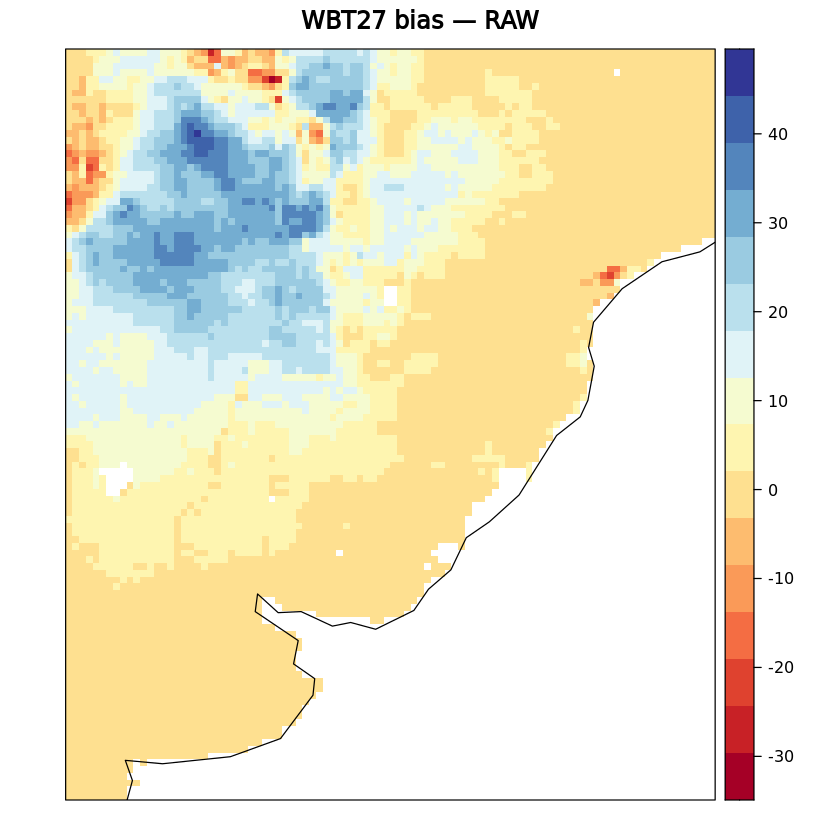

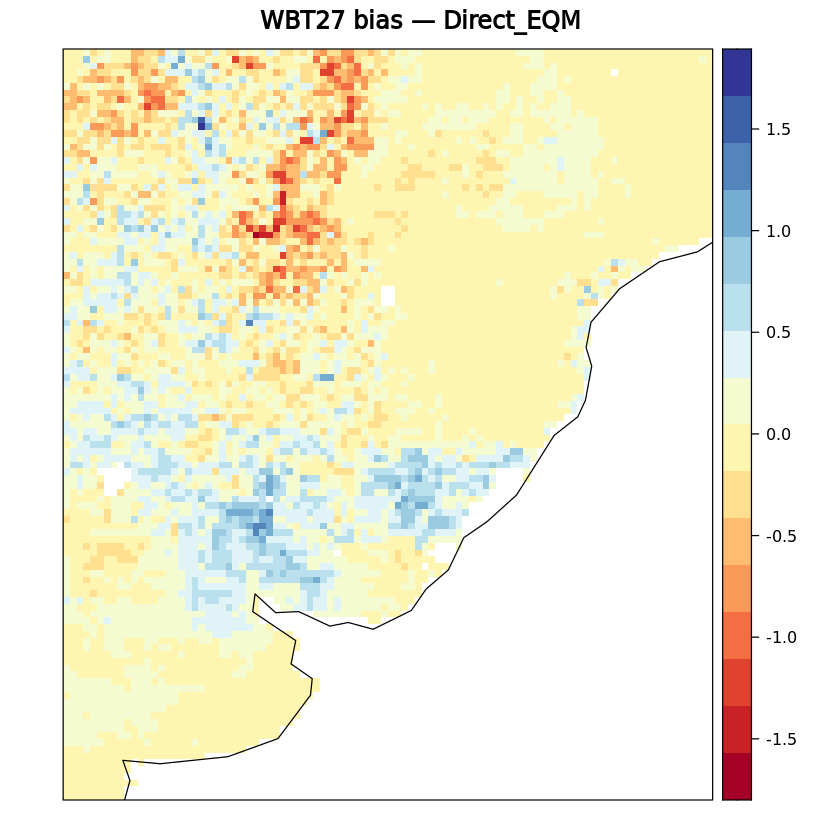

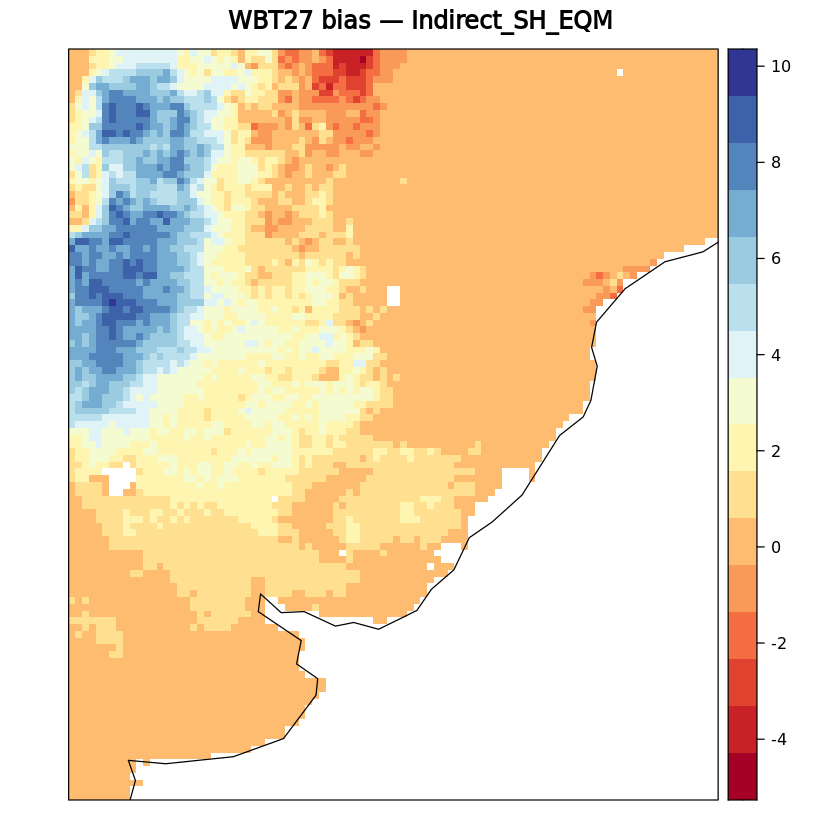

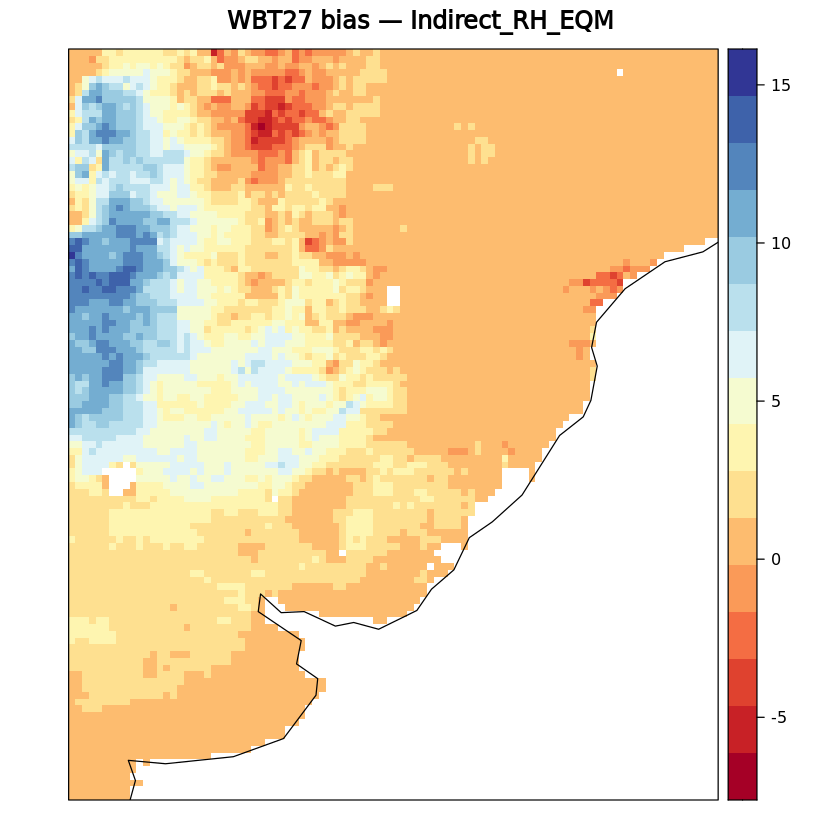

In [17]:
for (name in names(bias_wbt27)) {

  p= spatialPlot(
    bias_wbt27[[name]],
    main = paste("WBT27 bias —", name),
    backdrop.theme = "coastline"
  )

  print(p)
}

In [18]:
sessionInfo()

R version 3.6.3 (2020-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Rocky Linux 8.10 (Green Obsidian)

Matrix products: default
BLAS/LAPACK: /nfs/home/gmeteo/balmacedar/micromamba/envs/R363-climate4R/lib/libopenblasp-r0.3.30.so

locale:
 [1] LC_CTYPE=en_GB.UTF-8          LC_NUMERIC=C                 
 [3] LC_TIME=en_GB.UTF-8           LC_COLLATE=en_GB.UTF-8       
 [5] LC_MONETARY=en_GB.UTF-8       LC_MESSAGES=en_GB.UTF-8      
 [7] LC_PAPER=en_GB.UTF-8          LC_NAME=en_GB.UTF-8          
 [9] LC_ADDRESS=en_GB.UTF-8        LC_TELEPHONE=en_GB.UTF-8     
[11] LC_MEASUREMENT=en_GB.UTF-8    LC_IDENTIFICATION=en_GB.UTF-8

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] climate4R.indices_0.3.1 magrittr_2.0.1          HeatStress_1.0.8.1     
 [4] downscaleR_3.3.2        visualizeR_1.6.4        transformeR_2.1.2      
 [7] loadeR_1.7.1            climate4R.UDG_0.2.3     loadeR.java_1.2.1      